In [63]:
#We want to predict the height9dependent feature) on the basis of the weight

In [64]:
# Importing
# This is a comment written by the programmer.
# Python ignores this line completely.
# It is only used to describe what the next lines of code are doing.

import pandas as pd
# This line imports the 'pandas' library.
# Pandas is used for working with structured data like tables (rows and columns),
# similar to Excel sheets or CSV files.
# We rename (alias) pandas as 'pd' to make the code shorter and easier to write.
# Example: instead of writing pandas.read_csv(), we can write pd.read_csv().
# In linear regression, pandas is commonly used to:
# - Load datasets
# - Store input features (X) and output values (y)
# - Perform basic data inspection

import numpy as np
# This line imports the 'numpy' library.
# NumPy is used for numerical and mathematical operations.
# It provides fast arrays, matrices, and mathematical functions.
# We rename numpy as 'np' for convenience and readability.
# In linear regression, numpy is used for:
# - Handling numerical data
# - Performing mathematical calculations
# - Working with vectors and matrices (important for regression math)

import matplotlib.pyplot as plt
# This line imports the 'pyplot' module from matplotlib.
# Matplotlib is a library used for data visualization.
# 'pyplot' provides functions to create plots easily.
# We rename it as 'plt' to keep the code short.
# In linear regression, matplotlib is used to:
# - Plot data points (scatter plot)
# - Draw the regression line
# - Visually understand the relationship between X and y

In [65]:
#read the dataset
df = pd.read_csv('height-weight.csv')

In [66]:
df.head() #to see the records

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


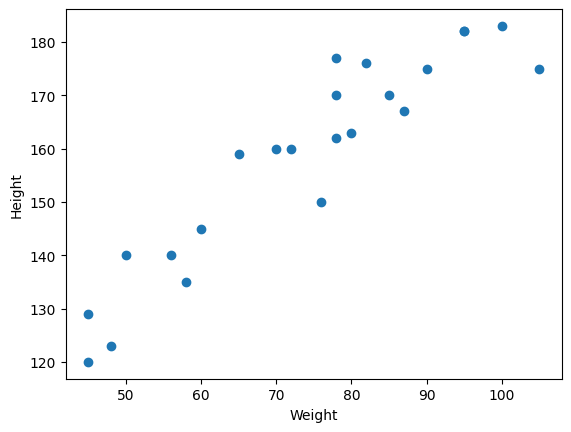

In [67]:
# plotting the scatter plot to visualise in 2D
plt.scatter(df['Weight'], df['Height'])
# plt.scatter() is a function from matplotlib used to create a scatter plot.
# A scatter plot shows individual data points as dots on a graph.
#
# df['Weight']:
# - This represents the values from the 'Weight' column of the DataFrame df.
# - These values are passed as the X-axis values.
# - Weight is the independent variable (input feature).
#
# df['Height']:
# - This represents the values from the 'Height' column of the DataFrame df.
# - These values are passed as the Y-axis values.
# - Height is the dependent variable (output/target).
#
# Why scatter plot?
# - It helps us visually check if there is a linear relationship
#   between Weight and Height.
# - If the points roughly form a straight line, linear regression is suitable.

plt.xlabel('Weight')


plt.ylabel('Height')

plt.show()
# plt.show() displays the plot on the screen.
# Without this line, the plot will not appear in most environments.
# This command tells Python to render and show the graph window.


In [68]:
# # Steps of ML:
# 1. Have the data set and divide the features based on indep. and dependent features.
# 2. Do the train test split
# 3. Standardise the data
# 4. Train the model
# 5. Make predictions
# 6. Evaluate and improve

In [69]:
#Step1:

# Dividing the data set into ind. and dep. features.
# It explains that the dataset is being split into:
# - Independent feature(s): input variable(s)
# - Dependent feature: output/target variable
# This is required for supervised learning algorithms like linear regression.

X = df[['Weight']]  # independent
# This line sele cts the 'Weight' column from the DataFrame df.
# df['Weight'] returns a pandas Series containing all Weight values.
#
# We assign it to the variable X because:
# - X conventionally represents the independent variable(s).
# - Weight is assumed to be the input that influences Height.
#
# In simple linear regression:
# - There is ONLY ONE independent variable.
# - That variable is plotted on the X-axis.
#
# At this point:
# - X is a pandas Series.
# - X contains numerical values of Weight.

y = df['Height']  # dependent
# This line selects the 'Height' column from the DataFrame df.
# df['Height'] returns a pandas Series containing all Height values.
#
# We assign it to the variable y because:
# - y conventionally represents the dependent variable.
# - Height is the output we want to predict.
#
# Height depends on Weight, so it is the dependent feature.
#
# At this point:
# - y is a pandas Series.
# - y contains numerical values of Height.

In [70]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [71]:
#Step2:

# now we do the train test split
# This comment explains that the dataset is now being divided into two parts:
# - Training data: used to train (learn) the linear regression model
# - Testing data: used to evaluate how well the model performs on unseen data

from sklearn.model_selection import train_test_split
# This line imports the 'train_test_split' function from scikit-learn.
# scikit-learn (sklearn) is a popular Python library for machine learning.
#
# train_test_split() is used to:
# - Randomly split data into training and testing sets
# - Ensure that the model is evaluated on data it has never seen before
#
# This helps prevent overfitting and gives a realistic measure of performance.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# This line performs the actual data splitting.
#
# X:
# - Independent feature(s) (Weight values)
#
# y:
# - Dependent feature (Height values)
#
# test_size = 0.2:
# - This means 20% of the data will be used for testing
# - The remaining 80% will be used for training
# - We choose 0.2 because it is a common and balanced split
#
# random_state = 42:
# - This fixes the randomness of the split
# - Using the same random_state ensures we get the SAME split every time
# - This is important for reproducibility and debugging
#
# Output variables:
# X_train → Weight values used for training the model
# X_test  → Weight values used for testing the model
# y_train → Height values corresponding to X_train
# y_test  → Height values corresponding to X_test


In [72]:
X.shape #Shape of the X

(23, 1)

In [73]:
X_train.shape  # Shape of the X_train
# X_train is the training portion of the independent variable (Weight).
# .shape is an attribute (not a function) that returns the dimensions of the data.
#
# For pandas Series or NumPy arrays, .shape returns:
# (number_of_rows, number_of_columns)  → if 2D
# (number_of_rows,)                   → if 1D
#
# This line is used to check:
# - How many training samples we have
# - Whether X_train is 1D or 2D
#
# This is important because most machine learning models
# expect X to be a 2D structure.

X_test.shape  # Shape of the X_test
# X_test is the testing portion of the independent variable.
# .shape again tells us the size and dimensionality of the test data.
#
# This confirms:
# - How many samples are kept for testing
# - Whether the shape matches what the model expects

(5, 1)

In [74]:
# Step 3:

# It indicates that we are now in the third step of the machine learning pipeline.
# This step focuses on preprocessing the data before training the model.

from sklearn.preprocessing import StandardScaler
# This line imports the 'StandardScaler' class from sklearn.preprocessing.
#
# sklearn.preprocessing contains tools used to prepare data
# before feeding it into machine learning models.
#
# StandardScaler is specifically used for feature scaling.
# It standardizes data using the formula:
#
#     z = (x - mean) / standard_deviation
#
# This transforms the data so that:
# - Mean becomes 0
# - Standard deviation becomes 1
#
# Feature scaling is important because:
# - Many ML algorithms are sensitive to feature magnitude
# - It improves numerical stability
# - It helps gradient-based algorithms converge faster

scaler = StandardScaler()
# This line creates an object (instance) of the StandardScaler class.
#
# We store it in a variable named 'scaler' so we can reuse it.
#
# At this point:
# - No data has been scaled yet
# - The scaler has not learned the mean or standard deviation
#
# This object will later:
# - Learn statistics (mean and std) from training data
# - Apply the same transformation to training and test data

In [75]:
X_train.head() #before applying

,Weight
12,105
1,58
13,100
5,78
2,48


In [76]:
X_train = scaler.fit_transform(X_train)
# This line performs TWO operations on the training data:
# 1. fit()
# 2. transform()
#
# Let's break it down:
#
# scaler:
# - This is the StandardScaler object we created earlier.
#
# fit_transform():
# - fit() calculates the MEAN and STANDARD DEVIATION of X_train.
# - transform() uses those values to scale X_train.
#
# Why do we FIT only on X_train?
# - The training data represents what the model is allowed to learn from.
# - If we used test data here, it would cause DATA LEAKAGE.
#
# What scaling does mathematically:
# For each value x in X_train:
#     scaled_x = (x - mean_of_X_train) / std_of_X_train
#
# After this line:
# - X_train is converted into a NumPy array
# - Mean of X_train ≈ 0
# - Standard deviation of X_train ≈ 1
# - X_train is now in a form suitable for ML models
#
# IMPORTANT:
# - X_train was previously a 1D structure (later changed to 2D)
# - fit_transform automatically reshapes it into a 2D array
#   of shape (number_of_samples, 1)

X_test = scaler.transform(X_test)
# This line scales the test data using the SAME scaler.
#
# transform():
# - Uses the mean and standard deviation learned from X_train
# - Does NOT recalculate them
#
# Why NOT fit_transform() on X_test?
# - The model must NOT learn anything from test data
# - Using fit() here would leak information from test data
#
# After this line:
# - X_test becomes a NumPy array
# - It is scaled using training statistics
# - Shape becomes (number_of_test_samples, 1)


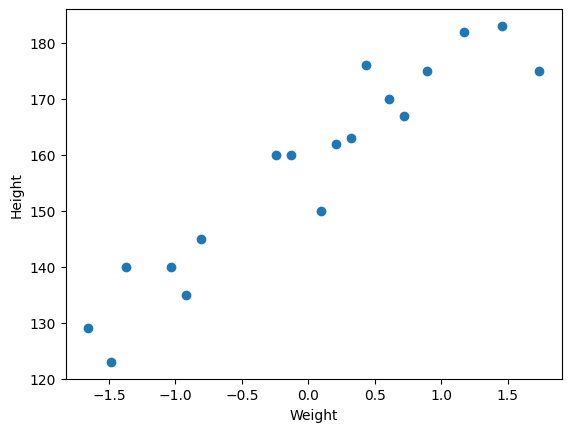

In [77]:
plt.scatter(X_train, y_train)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [78]:
# Step 4:
# This comment indicates that we are now in Step 4 of the machine learning workflow.
# Step 4 is where we create (initialize) the linear regression model.

from sklearn.linear_model import LinearRegression
# This line imports the LinearRegression class from sklearn.linear_model.
#
# sklearn.linear_model contains models that assume a linear relationship
# between input features and the target variable.
#
# LinearRegression implements Ordinary Least Squares (OLS),
# which finds the "best fit" line by minimizing the sum of squared errors.
#
# Mathematically, the model learns:
#     y = mX + c
# where:
# - m = slope (coefficient)
# - c = intercept

regressor = LinearRegression()
# This line creates an instance (object) of the LinearRegression class.
#
# We store it in a variable named 'regressor'.
#
# Why no arguments are passed?
# - LinearRegression has sensible default parameters.
# - For simple linear regression, defaults work perfectly.
#
# What happens internally:
# - A model object is created
# - No data is learned yet
# - No coefficients are calculated yet
#
# At this point:
# - regressor exists in memory
# - It is ready to be trained using .fit()

In [79]:
regressor.fit(X_train, y_train)
# This line trains (fits) the linear regression model using the training data.
#
# regressor:
# - This is the LinearRegression model object we created earlier.
# - It currently has no knowledge of the data.
#
# fit():
# - This method tells the model to learn from data.
# - It calculates the best-fitting straight line using Ordinary Least Squares (OLS).
#
# X_train:
# - This is the independent variable (Weight).
# - It is a 2D NumPy array of shape (number_of_training_samples, 1).
# - These are the input values used to predict the output.
#
# y_train:
# - This is the dependent variable (Height).
# - It contains the actual target values corresponding to X_train.
#
# Why both are needed:
# - X_train tells the model WHAT it should learn from.
# - y_train tells the model WHAT the correct answers are.
#
# Internally, the model:
# - Finds the slope (coefficient) that minimizes error
# - Finds the intercept (bias term)
# - Stores these learned parameters inside the regressor object
#
# Mathematically, it learns:
#     y = mX + c
# where:
# - m (slope) → regressor.coef_
# - c (intercept) → regressor.intercept_

LinearRegression()

In [80]:
print("The slope or coefficient of weights is:", regressor.coef_)
# print() is a built-in Python function used to display output on the screen.
#
# "The slope or coefficient of weights is:":
# - This is a string message to describe what is being printed.
#
# regressor.coef_:
# - This attribute stores the learned slope (m) of the regression line.
# - It represents how much Height changes when Weight increases by 1 unit.
# - The underscore (_) at the end indicates it was learned after fitting.
#
# Why comma is used:
# - print() can take multiple arguments separated by commas
# - Python automatically adds a space between them
#
# Output type:
# - regressor.coef_ is a NumPy array
# - For simple linear regression, it contains one value

print("The intercept of weights is:", regressor.intercept_)
# This line prints the intercept (c) of the regression line.
#
# regressor.intercept_:
# - This is the value of Height when Weight is 0.
# - It is the point where the regression line crosses the Y-axis.
#
# Like coef_, intercept_ is also learned during .fit()
# and stored inside the model object.


The slope or coefficient of weights is: [17.03440872]
The intercept of weights is: 157.5


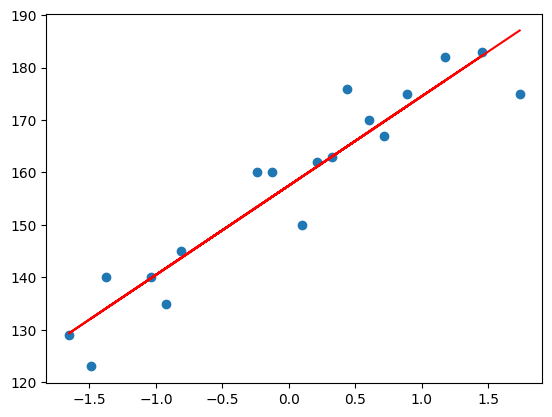

In [81]:
plt.scatter(X_train, y_train)
# plt.scatter() creates a scatter plot.
#
# X_train:
# - Independent variable (Weight) for training data
# - Each value is plotted on the X-axis
#
# y_train:
# - Dependent variable (Height) for training data
# - Each value is plotted on the Y-axis
#
# Purpose:
# - Visualize the training data points
# - Each dot represents one sample
# - Helps to see the spread and relationship between Weight and Height

plt.plot(X_train, regressor.predict(X_train), color='red')
# plt.plot() draws a line on the graph.
#
# X_train:
# - Same X values as scatter plot (Weight)
#
# regressor.predict(X_train):
# - This calculates predicted Height values using the trained model
# - The model applies: y = m*X + c
#
# color='red':
# - Sets the line color to red so it stands out from scatter points
#
# Purpose:
# - Draw the regression line that best fits the training data
# - Allows visual comparison between actual data points and model predictions

In [82]:
# Step 5:

# Prediction of train data
# 1. Predicted height output = intercept + coef_(weights)
# 2. y_pred_train = 157.5 + 17.03 * (X_train)
#
# Prediction on test data
# 1. Predicted height output = intercept + coef_(weights)
# 2. y_pred_test = 157.5 + 17.03 * (X_test)
#
# These comments explain the basic linear regression formula:
# - y_pred = m * X + c
# - m = regressor.coef_ (slope)
# - c = regressor.intercept_ (intercept)
# - X = input (Weight)
# - y_pred = predicted output (Height)

In [83]:
y_pred_test = regressor.predict(X_test)
# regressor.predict():
# - This method calculates the predicted Height values for the input data
# - It applies the learned linear equation: y = m*X + c
#
# X_test:
# - This is the testing independent data (Weight)
# - We want to see how the model predicts on unseen data
#
# y_pred_test:
# - Stores the predicted Height values corresponding to X_test
# - It will be a NumPy array of shape (number_of_test_samples, 1)
#
# Why we predict on X_test:
# - To evaluate model performance on data it has not seen
# - Helps us check generalization ability

In [84]:
y_pred_test, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

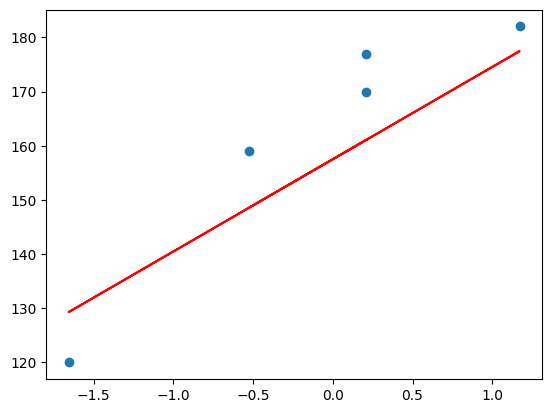

In [87]:
plt.scatter(X_test, y_test)
# plt.scatter() creates a scatter plot.
#
# X_test:
# - Independent variable (Weight) for testing data
# - Each value is plotted on the X-axis
#
# y_test:
# - Dependent variable (Height) for testing data
# - Each value is plotted on the Y-axis
#
# Purpose:
# - Visualize the actual test data points
# - Each dot represents one sample from the test set
# - Helps to see how the actual data compares with predictions

plt.plot(X_test, regressor.predict(X_test), color='red')
# plt.plot() draws a line on the graph.
#
# X_test:
# - Independent variable values for testing data
#
# regressor.predict(X_test):
# - This calculates predicted Height values for X_test using the trained model
# - The model applies the formula: y = m*X + c
#
# color='red':
# - Makes the regression line red for visibility
#
# Purpose:
# - Draw the regression line according to the model
# - Allows visual comparison between actual test points (scatter) and predicted line
# - Helps to see how well the model generalizes to unseen data

In [89]:
# performance metrics
# how well the trained linear regression model performs on test data.

In [92]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# This line imports three functions from scikit-learn to measure model performance:
#
# 1. mean_squared_error (MSE):
#    - Measures the average squared difference between actual and predicted values.
#    - Penalizes larger errors more heavily.
#
# 2. r2_score:
#    - Coefficient of determination.
#    - Measures how well the model explains the variation in y.
#    - 1 → perfect fit, 0 → poor fit.
#
# 3. mean_absolute_error (MAE):
#    - Measures the average absolute difference between actual and predicted values.
#    - Gives a simple, intuitive measure of error.

mse = mean_squared_error(y_test, y_pred_test)
# This calculates the Mean Squared Error on the test data.
#
# y_test:
# - Actual Height values for the test set.
#
# y_pred_test:
# - Predicted Height values from the model for the test set.
#
# What it tells us:
# - Average squared difference between predicted and actual heights.
# - Smaller MSE → better model performance.

mae = mean_absolute_error(y_test, y_pred_test)
# This calculates the Mean Absolute Error on the test data.
#
# What it tells us:
# - Average absolute difference between predicted and actual heights.
# - Provides a more interpretable error in the same units as the target variable.

rmse = np.sqrt(mse)
# RMSE = Root Mean Squared Error
#
# Why we calculate RMSE:
# - MSE squares errors, making the units squared (e.g., cm²)
# - Taking square root returns the error to the same unit as the target (cm)
# - Provides an intuitive sense of how far predictions are from actual values

print(mse)
# Prints the Mean Squared Error of the model on test data

print(mae)
# Prints the Mean Absolute Error of the model on test data

print(rmse)
# Prints the Root Mean Squared Error of the model on test data


109.77592599051664
9.822657814519232
10.477400726827081


In [93]:
# Accuracy
# This comment indicates that we are now computing how well the model predicts.
# In regression, “accuracy” is usually measured using R² score,
# not the same as classification accuracy.

In [94]:
from sklearn.metrics import r2_score
# This line imports the r2_score function from scikit-learn.
#
# r2_score:
# - Also called the coefficient of determination
# - Measures how much of the variation in the dependent variable (y) is explained by the model
# - Formula:
#       R² = 1 - (SS_res / SS_tot)
#       where:
#       SS_res = sum of squared residuals (errors)
#       SS_tot = total sum of squares (variance of actual values)
#
# Key points:
# - R² = 1 → perfect fit (model predicts all points exactly)
# - R² = 0 → model predicts no better than the mean of y
# - R² < 0 → model is worse than using the mean


In [96]:
score = r2_score(y_test, y_pred_test)
# This line calculates the R² score for the test data.
#
# y_test:
# - Actual values of the dependent variable (Height) in the test set
#
# y_pred_test:
# - Predicted values from the trained model
#
# The result (stored in variable 'score') tells us:
# - How well the model generalizes to unseen data
# - Higher score → better predictive performance

In [101]:
print(score)
# How to interpret R²:
# 0.92 → 92% of the variation in Height is explained by Weight
# Closer to 1 → model is very good
# Closer to 0 → model does not explain the variation well
# Negative R² → model performs worse than simply predicting the mean

0.776986986042344


In [102]:
1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
# This formula calculates the Adjusted R² score.
#
# Purpose:
# - R² can be artificially high if you add more features
# - Adjusted R² penalizes unnecessary features
# - It is more reliable for multiple regression
#
# Components:
# 1 - score
# - score = R² of the model
# - (1 - score) gives the proportion of unexplained variance
#
# len(y_test) - 1
# - Number of observations in test set minus 1
#
# len(y_test) - X_test.shape[1] - 1
# - Number of observations minus number of independent variables minus 1
# - Adjusts for model complexity
#
# Final formula:
# Adjusted R² = 1 - [(1 - R²) * (n - 1) / (n - p - 1)]
# where:
# - n = number of samples
# - p = number of features
#
# In simple linear regression:
# - X_test.shape[1] = 1 (one independent variable)
# - So formula reduces slightly

0.7026493147231252

In [103]:
# R² → Proportion of variance explained
# Adjusted R² → Adjusted for number of features
# # Always useful when comparing models with different numbers of predictors

In [111]:
# For a new data point say weight = 80
# This comment explains that we want to predict Height for a person
# whose Weight is 80 units (kg, lbs, etc. depending on dataset).

scaled_weight = scaler.transform([[80]])
# scaler.transform() scales the new data point using the same StandardScaler
# that was fitted on the training data.
#
# [[80]]:
# - The input must be 2D (rows × columns)
# - Outer brackets → 1 row (single sample)
# - Inner brackets → 1 column (one feature: Weight)
#
# Why scaling is necessary:
# - Our model was trained on **scaled features**
# - Any new input must be scaled in the same way
#
# After this line:
# - scaled_weight is a NumPy array
# - It contains the scaled value of 80 according to training mean & std

scaled_weight
# This line outputs the scaled value in the notebook/console.
# Example output might be something like:
# array([[0.85]])
#
# Interpretation:
# - The model does not use original units
# - It uses standardized units (z-scores)
# - This scaled value can now be passed to regressor.predict()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [114]:
print(regressor.predict(scaled_weight))
# print() is a built-in Python function that displays output on the screen.
#
# regressor.predict(scaled_weight):
# - regressor is the trained Linear Regression model
# - predict() takes the scaled input and calculates predicted Height using:
#       y = m * X_scaled + c
#
# scaled_weight:
# - The new Weight input after scaling (from StandardScaler)
# - Must be 2D: shape (1,1) because sklearn expects 2D arrays
#
# Output:
# - NumPy array containing the predicted Height
# - Example: array([167.5])
#
# Interpretation:
# - For Weight = 80, the model predicts Height ≈ 167.5 (units same as original dataset)
# - This allows you to apply the regression model to **new, unseen data**

[163.01076266]


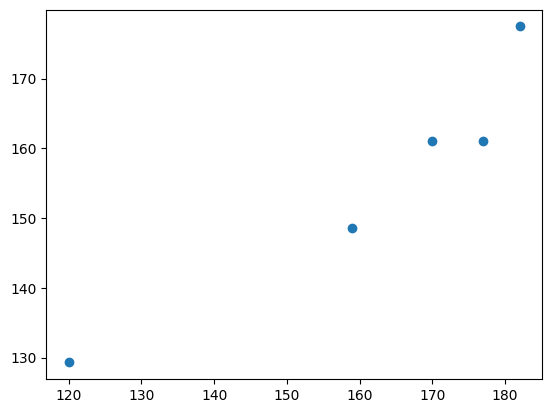

In [116]:
#Assumptionsfor LR (applicable to Multiple LR as well)

# Number 1:

plt.scatter(y_test, y_pred_test)
# plt.scatter() creates a scatter plot of the actual vs predicted values.
#
# y_test:
# - Actual target values (Height) from the test set
# - Plotted on the X-axis
#
# y_pred_test:
# - Predicted target values from the model
# - Plotted on the Y-axis
#
# Purpose:
# - Check linearity assumption of Linear Regression
# - Evaluate how close predictions are to actual values visually
#
# Interpretation:
# - If points lie roughly along a straight 45° line (y = x):
#     - Predictions match actual values well
#     - Model satisfies linearity assumption
# - If points are scattered randomly:
#     - Model may not fit data well
#     - Assumptions of linear regression may be violated

In [120]:
# Assumptions number 2:
# This comment indicates that we are now verifying the second assumption
# of Linear Regression, which is related to residuals.
#
# Residuals are the errors made by the model.
# They represent the difference between actual and predicted values.

residuals = y_test - y_pred_test
# This line calculates the residuals (errors) of the model.
#
# y_test:
# - Actual observed values of the dependent variable (Height)
#
# y_pred_test:
# - Predicted values produced by the regression model
#
# Subtraction (y_test - y_pred_test):
# - Computes how much the model's prediction differs from the actual value
#
# Residual formula:
#     residual = actual_value - predicted_value
#
# Interpretation:
# - residual > 0 → model under-predicted
# - residual < 0 → model over-predicted
# - residual ≈ 0 → very accurate prediction
#
# After this line:
# - 'residuals' contains an array/Series of errors for each test sample


residuals
# This line displays the residual values.
#
# In a Jupyter notebook:
# - The array/Series will be printed automatically
#
# In a Python script:
# - You would need print(residuals)
#
# Each value corresponds to:
# - One test data point
# - The error made by the model for that point


,Height
15,15.915329
9,8.915329
0,-9.304156
8,4.543549
17,10.434926


/tmp/ipython-input-2846328872.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde=True);


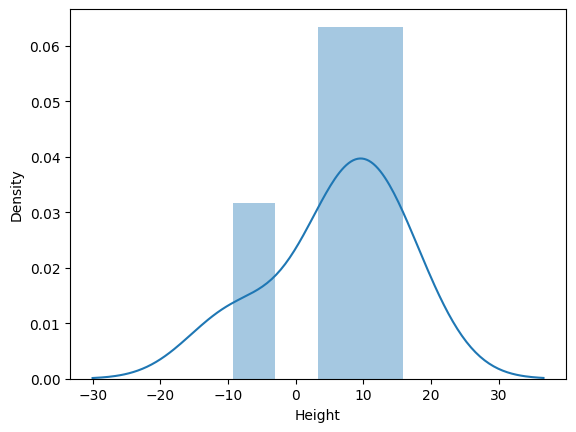

In [124]:
# Plotting these residuals
# This comment explains that we are now visualizing the residuals
# to understand their distribution.
#
# In Linear Regression, one important assumption is:
# - Residuals should be approximately normally distributed
import seaborn as sns
# This line imports the seaborn library.
#
# Seaborn is built on top of matplotlib and is used for
# creating more attractive and statistically informative plots.
#
# We use seaborn here because it provides easy functions
# for visualizing distributions.
sns.distplot(residuals, kde=True);
# sns.distplot() plots the distribution of a dataset.
#
# residuals:
# - These are the errors calculated as (y_test - y_pred_test)
# - We want to see how these errors are distributed
#
# kde=True:
# - KDE stands for Kernel Density Estimation
# - It draws a smooth curve that estimates the probability density
# - Helps visually check if the distribution is close to normal (bell-shaped)
#
# The semicolon (;) at the end:
# - Suppresses extra textual output in Jupyter Notebook
# - Does not affect the plot itself

In [125]:
#Assumption number 4:

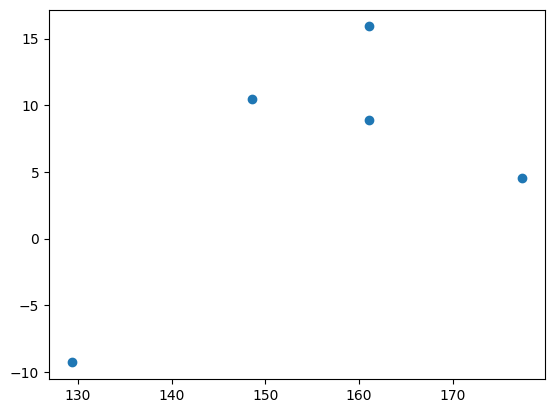

In [127]:
plt.scatter(y_pred_test, residuals)
# plt.scatter() creates a scatter plot.

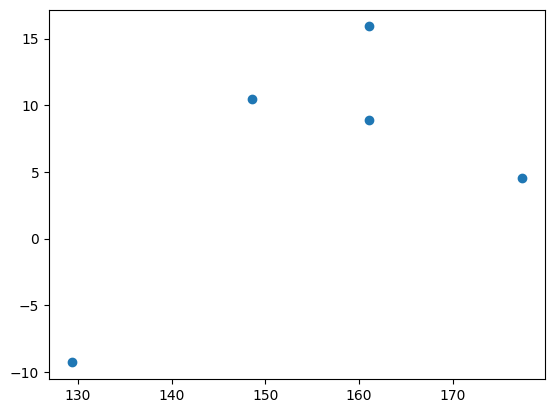

In [129]:
plt.scatter(y_pred_test, residuals)
# plt.scatter() creates a scatter plot.
#
# y_pred_test:
# - These are the predicted values from the regression model
# - They are plotted on the X-axis
#
# residuals:
# - These are the errors (actual - predicted values)
# - They are plotted on the Y-axis
#
# Purpose of this plot:
# - To check the homoscedasticity assumption of Linear Regression
# - To see whether residuals have constant variance across predictions
#
# What we expect to see (GOOD case):
# - Points randomly scattered around 0
# - Roughly equal spread above and below 0
# - No visible pattern or shape
#
# What indicates a problem (BAD case):
# - Funnel shape (variance increases or decreases)
# - Curved pattern (non-linearity)
# - Clusters or structure
#
# This plot helps verify that:
# - Errors are independent
# - Model is not systematically under- or over-predicting
